# Preparing for Results

There seems to be many changes I need to make to the way I wrangled results in order to run a model, this includes signs of purchases, keeping track of time and where price is moving to isolate for whales, and controlling for different markets, etc

Given that the other file was getting too convoluted I moved this last piece to here

In [8]:
import glob
import pandas as pd
import altair as alt
import statsmodels.formula.api as smf

alt.data_transformers.disable_max_rows()

dfs = []
whale_dfs = []
i = 1

def whale_hunting(csv_path: str, i: int):
    # Reading data
    market_test = pd.read_csv(csv_path)
    market_test = market_test.drop(
        columns=["name", "pseudonym", "bio", "profileImage", "profileImageOptimized", "transactionHash"],
        errors="ignore"
    )

    # Finding whales
    market_volume = market_test["size"].sum()
    WHALESHARE = 0.05
    whale_threshold = WHALESHARE * market_volume

    # If no whales in raw data, skip
    if (market_test["size"] >= whale_threshold).sum() == 0:
        return None, None

    # Full dataframe
    df = market_test.copy()

    # Convert price into one common outcome space:
    # this makes all prices interpreted from outcomeIndex == 1 perspective
    df["price_outcome"] = df["price"]
    df.loc[df["outcomeIndex"] == 0, "price_outcome"] = (
        1 - df.loc[df["outcomeIndex"] == 0, "price"]
    )

    # Parse time + clean
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
    df = df.dropna(subset=["timestamp", "price_outcome"]).sort_values("timestamp").copy()

    # Whale indicator on ALL trades
    df["is_whale"] = df["size"] >= whale_threshold

    # Plot graph
    market_graph = alt.Chart(df).mark_line().encode(
        alt.X("timestamp:T").title("Time"),
        alt.Y("price_outcome:Q").title("Price (Outcome Space)")
    ).properties(
        width=600,
        height=300,
        title="$ over time in common outcome space"
    )

    whale_points = alt.Chart(df[df["is_whale"]]).mark_point(
        filled=True, size=60, color="red"
    ).encode(
        alt.X("timestamp:T").title("Time"),
        alt.Y("price_outcome:Q").title("Price (Outcome Space)"),
        tooltip=[
            alt.Tooltip("proxyWallet:N", title="Wallet ID"),
            alt.Tooltip("outcomeIndex:Q", title="Outcome Index"),
            alt.Tooltip("side:N", title="Action"),
            alt.Tooltip("size:Q", title="Trade Size")
        ]
    )

    chart = (market_graph + whale_points).properties(
        width=600,
        height=300,
        title=f"$ over time with whale transactions: {csv_path}"
    )

    # Base series used to fetch future prices
    base = df[["timestamp", "price_outcome"]].sort_values("timestamp").copy()

    def price_after(trades_df: pd.DataFrame, horizon: pd.Timedelta) -> pd.Series:
        t = trades_df[["timestamp"]].copy()
        t["target_time"] = t["timestamp"] + horizon
        t["orig_idx"] = trades_df.index

        merged = pd.merge_asof(
            t.sort_values("target_time"),
            base.sort_values("timestamp"),
            left_on="target_time",
            right_on="timestamp",
            direction="nearest",
            allow_exact_matches=True
        )

        merged = merged.sort_values("orig_idx").set_index("orig_idx")
        return merged["price_outcome"]

    # Prices at horizons for ALL trades
    df["p_t"] = df["price_outcome"]
    df["p_1h"] = price_after(df, pd.Timedelta(hours=1))
    df["p_6h"] = price_after(df, pd.Timedelta(hours=6))
    df["p_12h"] = price_after(df, pd.Timedelta(hours=12))
    df["p_1d"] = price_after(df, pd.Timedelta(days=1))
    df["p_2d"] = price_after(df, pd.Timedelta(days=3))
    df["p_3d"] = price_after(df, pd.Timedelta(days=3))

    # Raw changes for ALL trades
    df["change_1h"] = df["p_1h"] - df["p_t"]
    df["change_6h"] = df["p_6h"] - df["p_t"]
    df["change_12h"] = df["p_12h"] - df["p_t"]
    df["change_1d"] = df["p_1d"] - df["p_t"]
    df["change_2d"] = df["p_2d"] - df["p_t"]
    df["change_3d"] = df["p_3d"] - df["p_t"]

    # Signed changes for ALL trades
    # BUY expects price to go up in this common outcome space
    # SELL expects price to go down
    df["direction"] = df["side"].map({"BUY": 1, "SELL": -1})
    df["signed_change_1h"] = df["direction"] * df["change_1h"]
    df["signed_change_6h"] = df["direction"] * df["change_6h"]
    df["signed_change_12h"] = df["direction"] * df["change_12h"]
    df["signed_change_1d"] = df["direction"] * df["change_1d"]
    df["signed_change_2d"] = df["direction"] * df["change_2d"]
    df["signed_change_3d"] = df["direction"] * df["change_3d"]

    # Time to resolution proxy
    resolution_time = df["timestamp"].max()
    df["time_to_resolution_h"] = (
        resolution_time - df["timestamp"]
    ).dt.total_seconds() / 3600

    # Market id for fixed effects later
    df["market_id"] = csv_path

    # Save ALL trades for pooled regression later
    dfs.append(df.copy())

    # Whale-only table for presentation
    whale_trades = df[df["is_whale"]].copy()
    whale_trades = whale_trades.sort_values("timestamp").copy()

    whale_trades["p_next_whale"] = whale_trades["price_outcome"].shift(-1)
    whale_trades["change_until_next_whale"] = (
        whale_trades["p_next_whale"] - whale_trades["price_outcome"]
    )
    whale_trades["hours_until_next_whale"] = (
        whale_trades["timestamp"].shift(-1) - whale_trades["timestamp"]
    ).dt.total_seconds() / 3600
    whale_trades["signed_change_next_whale"] = (
        whale_trades["direction"] * whale_trades["change_until_next_whale"]
    )

    whale_trade_table = whale_trades[
        [
            "timestamp", "proxyWallet", "side", "size", "price", "outcome", "outcomeIndex", "price_outcome", 
            "change_1h", "change_6h", "change_12h", "change_1d", "change_2d", "change_3d", "change_until_next_whale", 
            "signed_change_1h", "signed_change_6h", "signed_change_12h", "signed_change_1d", "signed_change_2d", "signed_change_3d", "signed_change_next_whale",
            "time_to_resolution_h"
        ]
    ].reset_index(drop=True)

    whale_trade_table = whale_trade_table.round(4)
    
    whale_dfs.append(whale_trade_table.copy())
    chart.save(f"charts/{i}.png")

    return chart, whale_trade_table


# Run over all markets
for csv_path in sorted(glob.glob("market_csvs/*_trades.csv")):
    chart, table = whale_hunting(csv_path, i)

    if table is not None:
        #display(chart)
        #display(table.head(10))
        i += 1



In [9]:
# Combine ALL trades across markets for regression
master_df = pd.concat(dfs, ignore_index=True)
master_df.describe()

,size,price,timestamp,outcomeIndex,price_outcome,p_t,p_1h,p_6h,p_12h,p_1d,...,change_2d,change_3d,direction,signed_change_1h,signed_change_6h,signed_change_12h,signed_change_1d,signed_change_2d,signed_change_3d,time_to_resolution_h
count,18916.000000,18916.000000,18916,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,...,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000,18916.000000
mean,144.410207,0.616967,2025-11-24 12:27:08.133748992,0.460933,0.462569,0.462569,0.461681,0.462213,0.462327,0.465395,...,0.021026,0.021026,0.350603,0.000161,0.001577,-0.000483,0.004811,0.006085,0.006085,746.409612
min,0.010000,0.001000,2023-11-29 21:58:08,0.000000,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,...,-0.956000,-0.956000,-1.000000,-0.929936,-0.956000,-0.956000,-0.956000,-0.956000,-0.956000,0.000000
25%,2.625000,0.320000,2025-10-25 14:43:40.500000,0.000000,0.045882,0.045882,0.042000,0.040000,0.032000,0.030000,...,-0.015000,-0.015000,-1.000000,-0.003000,-0.010000,-0.012000,-0.014000,-0.025000,-0.025000,74.794514
50%,13.330000,0.670000,2025-12-29 15:26:28,0.000000,0.400000,0.400000,0.400000,0.389530,0.404947,0.400000,...,0.001001,0.001001,1.000000,0.000000,0.000000,-0.000000,0.000000,-0.001000,-0.001000,182.449306
75%,57.464000,0.974000,2026-02-15 18:35:18,1.000000,0.900000,0.900000,0.910000,0.915000,0.920999,0.930000,...,0.043233,0.043233,1.000000,0.005000,0.010000,0.013000,0.020000,0.026823,0.026823,1022.910556
max,55871.000000,0.999000,2026-03-18 19:11:55,1.000000,0.999000,0.999000,0.999000,0.999000,0.999000,0.999000,...,0.960000,0.960000,1.000000,0.944000,0.945023,0.945023,0.950000,0.960000,0.960000,6062.687222
std,1324.882973,0.354834,NaN,0.498485,0.371736,0.371736,0.374388,0.378490,0.383054,0.388825,...,0.187615,0.187615,0.936549,0.062848,0.084254,0.106586,0.133804,0.188692,0.188692,1176.890597


In [10]:
master_whale_df = pd.concat(whale_dfs, ignore_index=True)
master_whale_df.describe()

,timestamp,size,price,outcomeIndex,price_outcome,change_1h,change_6h,change_12h,change_1d,change_2d,change_3d,change_until_next_whale,signed_change_1h,signed_change_6h,signed_change_12h,signed_change_1d,signed_change_2d,signed_change_3d,signed_change_next_whale,time_to_resolution_h
count,77,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,49.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,49.000000,77.000000
mean,2025-11-05 10:23:40.805194496,11493.202497,0.677152,0.519481,0.595817,-0.006299,0.000806,0.002464,0.013048,0.010871,0.010871,0.011676,-0.010317,-0.003175,-0.000817,0.008271,0.008149,0.008149,0.007153,665.031792
min,2023-11-30 16:55:17,498.166300,0.001000,0.000000,0.001000,-0.457400,-0.200900,-0.200900,-0.200900,-0.489000,-0.489000,-0.474800,-0.457400,-0.200900,-0.200900,-0.200900,-0.489000,-0.489000,-0.474800,0.000000
25%,2025-07-30 17:09:41,1256.540000,0.326700,0.000000,0.020000,0.000000,-0.001700,-0.001300,-0.001300,-0.003900,-0.003900,-0.006000,-0.001300,-0.006600,-0.002100,-0.004800,-0.007800,-0.007800,-0.008400,2.101100
50%,2026-02-04 16:58:25,3644.250000,0.949400,1.000000,0.874400,0.000000,0.000000,0.000000,0.001000,0.000000,0.000000,0.000900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,79.361100
75%,2026-02-23 17:18:38,10186.390000,0.994000,1.000000,0.990900,0.006400,0.010000,0.009000,0.010200,0.009000,0.009000,0.020000,0.001000,0.008000,0.006900,0.007300,0.008600,0.008600,0.017300,400.095000
max,2026-03-18 18:41:41,55871.000000,0.999000,1.000000,0.999000,0.080000,0.110600,0.124900,0.718900,0.814900,0.814900,0.798900,0.038000,0.110600,0.124900,0.718900,0.814900,0.814900,0.798900,6025.654700
std,NaN,16481.233906,0.406351,0.502897,0.433146,0.061085,0.040546,0.044127,0.093085,0.121281,0.121281,0.143314,0.060528,0.040428,0.044189,0.093638,0.121497,0.121497,0.143617,1542.936652


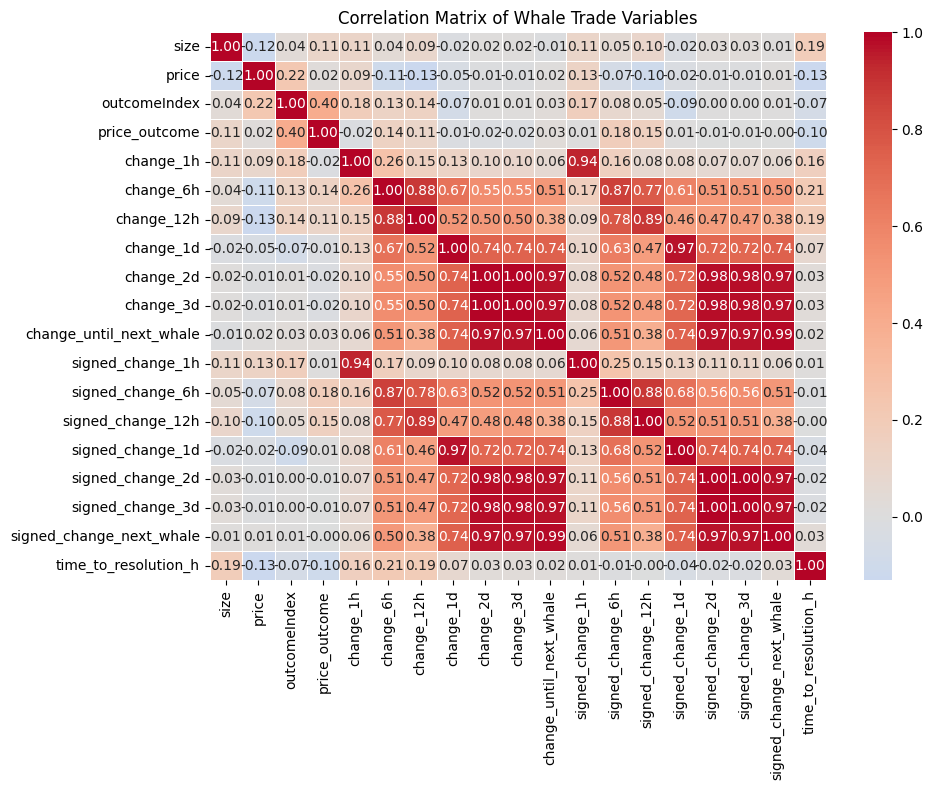

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# select only numeric columns
numeric_df = master_whale_df.select_dtypes(include="number")
corr = numeric_df.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Whale Trade Variables")
plt.tight_layout()
plt.show()

In [12]:
# Regression dataset
reg_df = master_df.dropna(subset=[
    "signed_change_1d",
    "time_to_resolution_h",
    "price_outcome",
    "direction"
]).copy()

In [13]:
# OLS with market fixed effects
models = {}

for h in ["6h", "12h", "1d", "2d", "3d"]:
    model = smf.ols(
        f"signed_change_{h} ~ is_whale + time_to_resolution_h + price_outcome + C(market_id)",
        data=reg_df
    ).fit(cov_type="cluster", cov_kwds={"groups": reg_df["market_id"]})
    
    models[h] = model
    print(f"\n===== {h} =====")
    print(model.summary())

results = []

for h, model in models.items():
    coef = model.params["is_whale[T.True]"]
    se = model.bse["is_whale[T.True]"]
    t = model.tvalues["is_whale[T.True]"]
    
    results.append({
        "horizon": h,
        "coef": coef,
        "se": se,
        "t_stat": t
    })

results_df = pd.DataFrame(results)
print(results_df)


===== 6h =====
                            OLS Regression Results                            
Dep. Variable:       signed_change_6h   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     11.25
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           5.76e-05
Time:                        19:59:13   Log-Likelihood:                 20145.
No. Observations:               18916   AIC:                        -4.023e+04
Df Residuals:                   18885   BIC:                        -3.998e+04
Df Model:                          30                                         
Covariance Type:              cluster                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

/Users/ignaciomijares/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Users/ignaciomijares/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Users/ignaciomijares/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Users/ignaciomijares/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30

# Ignacio ToDo
- make sure signs and everything is correct, i.e effects are being measured correctly and not canceling each other out
- update current write up to tease at the power of aggregating information over the might of large traders

# Conclusion

Whales have no statistically significant effect on prices at every time horizon or definition of whale, that is to say, due to the nature of prediction markets and aggregating information their large volume has no statistically significant effect on prices, even when they are as large at 20% of market volume. 

You can hunt for whales all you want, in different sizes, markets, and time frames... The vast ocean of information that prediction markets create make their effects insignificant to other traders.

<img src="other/deadwhales.jpg" width="50%">

Where to go from here:
- It would be interesting to explore if this holds true in markets that have over 3500 transactions (roughly 500k+ USD in Volume), would information disipate or the true economic strength of whales cause real effects
- How big would a whale have to be to actually affect a market

In [ ]:
![Whale Caught](other/whalecaught.jpg)